# Financial Data Group Project


Before running the notebook, install the packages listed in `requirements.txt`. A virtual environment is recommended so the package versions do not conflict with the system Python.

```
numpy
pandas
yfinance
pandas-ta-classic
matplotlib
seaborn
scikit-learn
scipy
jupyterlab
openpyxl
```

## Imports and package versions

The version check is useful because `pandas-ta-classic` output can change between releases. This run uses pandas 3.0.3 and pandas-ta-classic 0.6.52.


In [1]:
import numpy as np
import pandas as pd
import pandas_ta_classic as ta
import yfinance as yf
import re
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LassoCV
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler


In [2]:
# check pandas and ta version cos takes sometimes to debugs this local due to version conflicts
print(pd.__version__)
print(ta.version)

3.0.3
0.6.52


## Part 1: Assessing Models with Alternative Data

This section follows the IVV example in *An Intelligent Approach for Predicting Stock Market Movements in Emerging Markets Using Optimized Technical Indicators and Neural Networks*. The goal is to reproduce the main data preparation steps, compare feature-screening methods, and evaluate an MLP with cross-validation.


### Download IVV data

The paper uses data from 2009-12-12 to 2020-01-01. Because 2009-12-12 was a Saturday and the end date is exclusive in `yfinance`, the returned trading dates are 2009-12-14 to 2019-12-31.

`auto_adjust=False` is required here. Otherwise, `yfinance` adjusts Open/High/Low/Close for distributions and the Open summary no longer matches Table 2.


In [3]:
# download IVV (raw prices)
ticker = "IVV"
start_date = "2009-12-12"
end_date = "2020-01-01"

df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)
df.head(10)



[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,IVV,IVV,IVV,IVV,IVV,IVV
Date,,,,,,
2009-12-14,83.156876,112.230003,112.360001,111.730003,112.250000,3201000
2009-12-15,82.756744,111.690002,112.290001,111.370003,111.849998,2537100
2009-12-16,82.912323,111.900002,112.489998,111.650002,112.180000,2842400
2009-12-17,81.860199,110.480003,111.269997,110.440002,111.080002,7247700
2009-12-18,82.378822,111.180000,111.250000,110.220001,111.139999,4320400
2009-12-21,83.142014,112.209999,112.650002,111.690002,111.699997,2675400
2009-12-22,83.468056,112.650002,113.000000,112.379997,112.519997,2204700
2009-12-23,83.675529,112.930000,113.059998,112.470001,113.029999,5763500


In [4]:
# flatten yfinance multiindex columns, then add technical indicators
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [
        "_".join([str(col) for col in multi_col if col]).strip()
        for multi_col in df.columns
    ]

df.ta.cores = 0
df.ta.strategy("All")

In [5]:
df.head()

,Adj Close_IVV,Close_IVV,High_IVV,Low_IVV,Open_IVV,Volume_IVV,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,...,VWMA_10,VWMACD_12_26_9,VWMACDh_12_26_9,VWMACDs_12_26_9,WAD,WCP,WILLR_14,WMA_10,ZL_EMA_10,ZS_30
Date,,,,,,,,,,,,,,,,,,,,,
2009-12-14,83.156876,112.230003,112.360001,111.730003,112.250000,3201000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.000000,112.137503,NaN,NaN,NaN,NaN
2009-12-15,82.756744,111.690002,112.290001,111.370003,111.849998,2537100,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-0.599998,111.760002,NaN,NaN,NaN,NaN
2009-12-16,82.912323,111.900002,112.489998,111.650002,112.180000,2842400,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-0.349998,111.985001,NaN,NaN,NaN,NaN
2009-12-17,81.860199,110.480003,111.269997,110.440002,111.080002,7247700,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-1.769997,110.667501,NaN,NaN,NaN,NaN
2009-12-18,82.378822,111.180000,111.250000,110.220001,111.139999,4320400,111.503335,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-0.809998,110.957500,NaN,NaN,NaN,NaN


After adding the full `pandas-ta-classic` strategy, the frame contains 413 columns in total. The paper reports 216 features, so the cleaning step below reduces the current library output to 216 columns.


In [6]:
# make sure index is datetime
df.index = pd.to_datetime(df.index)
df.index

DatetimeIndex(['2009-12-14', '2009-12-15', '2009-12-16', '2009-12-17',
               '2009-12-18', '2009-12-21', '2009-12-22', '2009-12-23',
               '2009-12-24', '2009-12-28',
               ...
               '2019-12-17', '2019-12-18', '2019-12-19', '2019-12-20',
               '2019-12-23', '2019-12-24', '2019-12-26', '2019-12-27',
               '2019-12-30', '2019-12-31'],
              dtype='datetime64[s]', name='Date', length=2529, freq=None)

### Open Price Analysis


#### Descriptive statistics

The following summary uses the unadjusted IVV Open series before technical-indicator cleaning.


In [7]:
open_values = df['Open_IVV']

minimum = np.min(open_values)
q1 = np.percentile(open_values, 25)      # 1st quartile (25th percentile)
median = np.median(open_values)          # 50th percentile 
mean = np.mean(open_values)
q3 = np.percentile(open_values, 75)      # 3rd quartile (75th percentile)
maximum = np.max(open_values)

df_stats = pd.DataFrame.from_dict({
    "Minimum": round(minimum, 1), 
    "1st Quartile": round(q1, 1), 
    "Median": round(median, 1),
    "Mean": round(mean, 1), 
    "3rd Quartile": round(q3, 1), 
    "Maximum": round(maximum, 1), 
}, orient="index")

df_stats.columns = [ticker]

In [8]:
df_stats

,IVV
Minimum,103.5
1st Quartile,138.3
Median,199.4
Mean,197.0
3rd Quartile,244.8
Maximum,325.2


The Open statistics are close to Table 2 in the paper:

- minimum: 103.5 (paper: 103.5)
- first quartile: 138.3 (paper: 137.9)
- median: 199.4 (paper: 199.3)
- mean: 197.0 (paper: 196.7)
- third quartile: 244.8 (paper: 244.7)
- maximum: 325.2 (paper: 325.2)

The small differences in the quartile and mean values are consistent with rounding or later revisions to Yahoo's historical data.


#### Open price over time


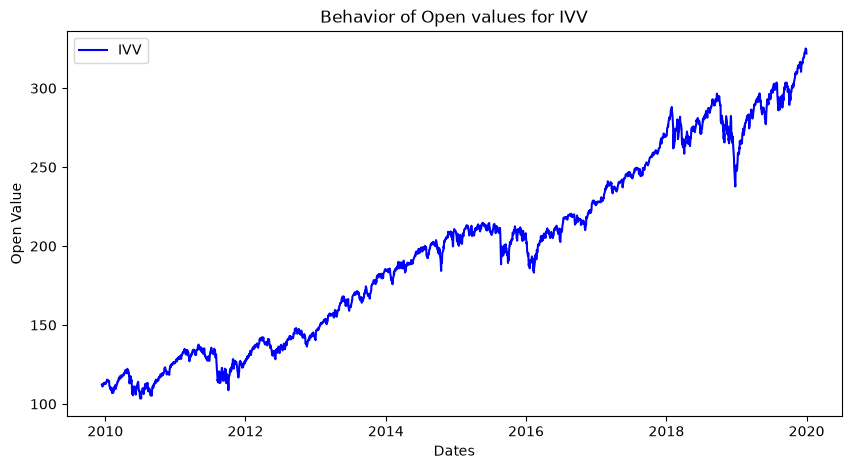

In [9]:
fig, ax = plt.subplots(figsize = (10, 5))

ax.plot(df.index, open_values, color = 'blue', label = ticker)
ax.set_ylabel('Open Value')
ax.set_xlabel('Dates')
ax.set_title('Behavior of Open values for IVV')

plt.legend()
plt.show() 

The Open series has the same general pattern as the IVV line in Figure 2: it starts near 112 in late 2009 and trends upward to roughly 322 by the end of 2019, with several drawdowns along the way.


### Γ Cumulative Movement

For each day, gamma is 1 when the next trading day's Open is higher and -1 otherwise. The cumulative sum shows the balance between upward and downward open-to-open moves.


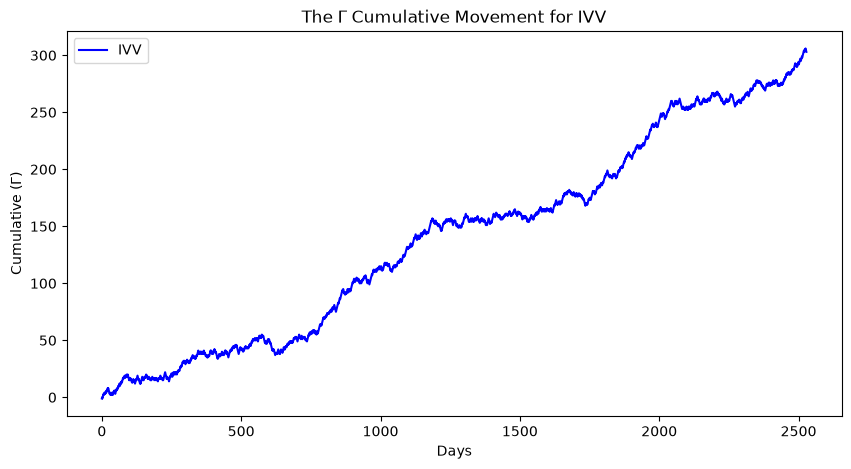

In [10]:
# gamma = 1 if next open is higher, else -1
gamma = np.where(open_values < open_values.shift(-1), 1, -1).squeeze()

days = [i for i in range(len(gamma))]
cumulative_gamma = gamma.cumsum()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(days, cumulative_gamma, color="blue", label=ticker)
ax.set_ylabel("Cumulative (Γ)")
ax.set_xlabel("Days")
ax.set_title("The Γ Cumulative Movement for IVV")

plt.legend()
plt.show()

The cumulative gamma series has an overall upward drift, which is consistent with the IVV pattern in Figure 3. The final observation should not be used as a model label because no next-day Open is available; it is removed when `X` and `y` are prepared below.


### Data Cleaning

Technical indicators introduce missing values, mainly because rolling calculations require a lookback period. With the current `pandas-ta-classic` release, the indicator frame has 413 columns rather than the paper's 216.

The current implementation:

1. ranks columns by missing-value count;
2. drops the 197 columns with the most missing values, leaving 216;
3. drops rows that still contain a missing value.

This is a practical approximation of the paper's 216-feature dataset. It does not guarantee that the retained feature names are identical to the authors' original version of Pandas TA.


In [11]:
TARGET_COLS = 216

rows_before = len(df)
cols_before = df.shape[1]

# drop columns with most NaNs first until we have 216 left
nan_counts = df.isna().sum().sort_values(ascending=False)
n_drop = max(0, df.shape[1] - TARGET_COLS)
cols_dropped_for_nan = nan_counts.index[:n_drop].tolist()
df = df.drop(columns=cols_dropped_for_nan)

print(f"Columns after trim: {df.shape[1]} (dropped {len(cols_dropped_for_nan)})")
print("Highest-NaN columns dropped (first 10):")
print(nan_counts.head(10))

# drop any remaining incomplete days
df = df.dropna(how="any").copy()

print(f"\nRows: {rows_before} -> {len(df)} (dropped {rows_before - len(df)})")
print(f"Cols: {cols_before} -> {df.shape[1]}")
print(f"Date range: {df.index.min().date()} -> {df.index.max().date()}")
print(f"Missing values left: {int(df.isna().sum().sum())}")
df.head()

Columns after trim: 216 (dropped 197)
Highest-NaN columns dropped (first 10):
ASIN               2529
ACOS               2529
PSARs_0.02_0.2     1580
SUPERTs_7_3.0      1566
QQEs_14_5_4.236    1468
HILOs_13_21        1410
QQEl_14_5_4.236    1131
SUPERTl_7_3.0       969
PSARl_0.02_0.2      950
HILOl_13_21         687
dtype: int64

Rows: 2529 -> 2520 (dropped 9)
Cols: 413 -> 216
Date range: 2009-12-28 -> 2019-12-31
Missing values left: 0


,Adj Close_IVV,Close_IVV,High_IVV,Low_IVV,Open_IVV,Volume_IVV,ABER_ZG_5_15,AD,ADD,AMATe_LR_8_21_2,...,TOS_STDEVALL_L_3,TOS_STDEVALL_U_3,TRUERANGE_1,TRUNC,TTM_TRND_6,TYPPRICE,VWAP_D,WAD,WCP,WMA_10
Date,,,,,,,,,,,,,,,,,,,,,
2009-12-28,84.269943,113.129997,113.339996,112.680000,113.279999,2157000,112.710000,1.629566e+06,226.259995,0,...,-81.565408,274.800466,0.659996,113.0,1,113.049998,113.049998,1.570000,113.069998,112.400909
2009-12-29,84.158195,112.980003,113.430000,112.919998,113.430000,1766900,112.895333,2.784413e+05,225.960007,0,...,-81.485432,274.880441,0.510002,112.0,1,113.110001,113.110001,1.120003,113.077501,112.554910
2009-12-30,84.091179,112.889999,113.000000,112.529999,112.610001,2501300,112.921333,1.608917e+06,225.779999,0,...,-81.405457,274.960416,0.470001,112.0,1,112.806666,112.806666,1.010002,112.827499,112.678909
2009-12-31,83.286674,111.809998,113.139999,111.610001,113.099998,3000900,112.794667,-6.074458e+05,223.619995,0,...,-81.325482,275.040392,1.529999,111.0,-1,112.186666,112.186666,-0.320000,112.092499,112.584727
2010-01-04,84.657288,113.650002,113.739998,112.709999,112.769997,3574200,112.903999,2.342161e+06,227.300003,0,...,-81.245506,275.120367,1.930000,113.0,1,113.366666,113.366666,1.520004,113.437500,112.826727


The cleaning run reduces the data from 413 to 216 columns and from 2,529 to 2,520 trading days. The cleaned period is 2009-12-28 to 2019-12-31, and no missing values remain.


### Feature Evaluation

Two feature-screening methods from the paper are applied:

- **Dispersion Ratio (DR):** an unsupervised measure of variability for strictly positive features;
- **LASSO:** a supervised L1 regression that shrinks weak coefficients to zero using gamma as the target.


#### Dispersion Ratio

For a positive feature, the arithmetic mean, geometric mean, and dispersion ratio are

$$
\bar{x} = \frac{1}{N}\sum_{i=1}^{N} x_i,
\qquad
\bar{x}_g = \left(\prod_{i=1}^{N} x_i\right)^{1/N},
\qquad
DR = \frac{\bar{x}}{\bar{x}_g}.
$$

A value near 1 indicates low dispersion; a larger value indicates greater dispersion. DR is only valid for features that remain strictly positive.

`EXP`, `SINH`, and `COSH` generate extremely large values when applied directly to price levels, so they are excluded from the ranking. The code also removes non-finite or implausibly large DR values.


In [12]:
def get_dispersion_ratio(df: pd.DataFrame) -> pd.Series:
    # paper formula; only columns that stay > 0
    pos = df.loc[:, (df > 0).all(axis=0)]
    arithmetic_mean = pos.mean(axis=0)
    geometric_mean = np.exp(np.log(pos).mean(axis=0))
    dr = arithmetic_mean / geometric_mean
    dr = dr.replace([np.inf, -np.inf], np.nan).dropna()

    # EXP/SINH/COSH explode on price levels -> useless rankings
    bad = [c for c in dr.index if c in {"EXP", "SINH", "COSH"} or dr[c] > 100]
    return dr.drop(labels=bad).sort_values(ascending=False)


In [13]:
dr = get_dispersion_ratio(df)
print(f"Positive features used for DR: {len(dr)} / {df.shape[1]}")
print("\nTop 10 DR:")
print(dr.head(10).to_frame("DR"))

ohlcv = [
    c for c in ["Volume_IVV", "Adj Close_IVV", "Close_IVV", "High_IVV", "Low_IVV", "Open_IVV"]
    if c in dr.index
]
print("\nOHLCV DR:")
print(dr.loc[ohlcv].to_frame("DR") if ohlcv else "(none)")


Positive features used for DR: 91 / 216

Top 10 DR:
                       DR
THERMO_20_2_0.5  1.468233
PSARaf_0.02_0.2  1.305669
BBP_5_2.0        1.284128
BBB_5_2.0        1.255945
TRUERANGE_1      1.204899
MULT             1.198169
PDIST            1.181312
PVOL             1.166789
STOCHFd_5_3      1.146222
MARKETFI         1.133008

OHLCV DR:
                     DR
Volume_IVV     1.110809
Adj Close_IVV  1.067624
Close_IVV      1.048323
High_IVV       1.048111
Low_IVV        1.048647
Open_IVV       1.048342


Of the 216 cleaned columns, 94 are strictly positive. After excluding `EXP`, `SINH`, and `COSH`, 91 features remain in the DR ranking.

The leading indicators are:

- `THERMO_20_2_0.5`: 1.468
- `PSARaf_0.02_0.2`: 1.306
- `BBP_5_2.0`: 1.284
- `BBB_5_2.0`: 1.256
- `TRUERANGE_1`: 1.205

For the original market fields, Volume has the highest DR (1.111), followed by Adjusted Close (1.068). Open, High, Low, and Close are all close to 1.048. This means several technical indicators are more dispersed than the raw price fields under this measure.


#### Labels and scaling

The cleaned data contains 2,520 days. The final day is removed because its next-day Open is unavailable, leaving 2,519 observations and 216 features. The target contains 1,410 upward moves and 1,109 downward moves.

All features are min-max scaled before LASSO and the MLP. In this notebook the scaler is fitted once to the full feature matrix. For a strict out-of-sample evaluation, scaling and supervised feature selection should instead be fitted inside each training fold to avoid leakage from the held-out fold.


In [14]:
# label: 1 if next open is higher than today, else -1
open_col = next(c for c in df.columns if c.startswith("Open"))
y = np.where(df[open_col].shift(-1) > df[open_col], 1, -1)

# last day has no next open
X = df.iloc[:-1].copy()
y = y[:-1]

# min-max scale features
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    index=X.index,
    columns=X.columns,
)

print(f"X shape: {X_scaled.shape}, y shape: {y.shape}")
print(f"Class balance: {(y == 1).sum()} up / {(y == -1).sum()} down")



X shape: (2519, 216), y shape: (2519,)
Class balance: 1410 up / 1109 down


#### LASSO

`LassoCV` uses five-fold internal cross-validation to select the L1 penalty. Features whose fitted coefficients are exactly zero are removed; the remaining features are ranked by absolute coefficient size.

This follows the paper's use of LASSO as a feature-selection measure, although gamma is a binary target and LASSO is a regression model rather than a classification-specific selector.


In [15]:
# L1 regression on gamma; cv picks lambda
lasso = LassoCV(cv=5, random_state=42, max_iter=5000, n_jobs=-1)
lasso.fit(X_scaled, y)

lasso_coefs = pd.Series(lasso.coef_, index=X_scaled.columns)
lasso_selected = lasso_coefs[lasso_coefs != 0].abs().sort_values(ascending=False)

print(f"alpha (lambda) chosen by CV: {lasso.alpha_:.6g}")
print(f"non-zero features: {len(lasso_selected)} / {X_scaled.shape[1]}")
print("\nTop 20 by |coefficient|:")
print(lasso_selected.head(20).to_frame("abs_coef"))


alpha (lambda) chosen by CV: 0.00292735
non-zero features: 21 / 216

Top 20 by |coefficient|:
                 abs_coef
BOP              2.462263
CDL_INSIDE       0.239033
CDL_LONGLINE     0.201390
CDL_DOJISTAR     0.132579
CDL_SHORTLINE    0.125337
CDL_SPINNINGTOP  0.099648
PSARaf_0.02_0.2  0.097948
MSW_LEAD_5       0.057859
AD               0.054319
CDL_RICKSHAWMAN  0.052614
SIN              0.051323
CDL_HANGINGMAN   0.035609
QQEd_14_5_4.236  0.025149
COS              0.023945
CDL_ENGULFING    0.021490
MSW_SINE_5       0.016757
SAREXT           0.013763
HT_TRENDMODE     0.013267
SUPERTd_7_3.0    0.011277
CDL_HIGHWAVE     0.010668


The selected penalty is $\alpha = 0.00292735$. LASSO retains 21 of the 216 features.

`BOP` has the largest absolute coefficient (2.462), followed by `CDL_INSIDE` (0.239), `CDL_LONGLINE` (0.201), `CDL_DOJISTAR` (0.133), and `CDL_SHORTLINE` (0.125). The complete non-zero ranking is stored in `lasso_selected` and the next chart shows the top 20.


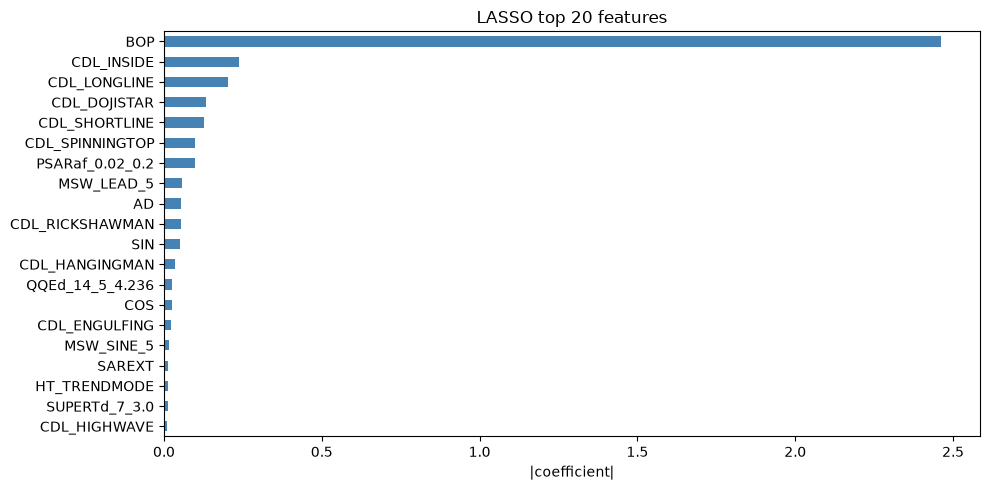

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
top_n = min(20, len(lasso_selected))
lasso_selected.head(top_n).iloc[::-1].plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("|coefficient|")
ax.set_title(f"LASSO top {top_n} features")
plt.tight_layout()
plt.show()


### Model Validation

The model predicts next-day Open direction from the 216 scaled features. Validation follows Algorithm 1 in the paper: shuffle the observations, create 10 stratified folds, train on nine folds, and evaluate on the remaining fold.


#### Shuffled 10-fold cross-validation

Each fold uses a newly created MLP. Starting with a fresh model prevents information learned in one fold from carrying into another. The same random seed gives each fold a reproducible initialization; using the same initialization is not itself what prevents data leakage.

The current split is stratified so that the proportion of upward and downward labels is similar across folds.


#### MLP configuration

The MLP uses one hidden layer. With 216 input features and two classes, the paper's rule gives

$$
\frac{216 + 2}{2} = 109
$$

hidden units. The baseline model uses logistic activation, the L-BFGS solver, a maximum of 5,000 iterations, and no early stopping. A fresh instance is built for every fold.

Table 6 below repeats the experiment with early stopping enabled.


In [17]:
def build_mlp(
    n_features: int,
    y: np.ndarray,
    random_state: int = 42,
    early_stopping: bool = False,
) -> MLPClassifier:
    # hidden size = (n_features + n_classes) / 2, same as paper
    hidden_layer_sizes = int((n_features + len(np.unique(y))) / 2)
    # sklearn only applies early_stopping for adam/sgd; lbfgs ignores it
    solver = "adam" if early_stopping else "lbfgs"
    return MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation="logistic",
        solver=solver,
        batch_size="auto",
        learning_rate="adaptive",
        learning_rate_init=0.03,
        max_iter=5000,
        momentum=0.2,
        random_state=random_state,
        early_stopping=early_stopping,
        validation_fraction=0.1,
        n_iter_no_change=10,
    )


#### Cross-validation loop


In [18]:
def cross_validation(
    X,
    y,
    k: int = 10,
    random_state: int = 42,
    early_stopping: bool = False,
    track_fit_stats: bool = False,
):
    # Algorithm 1: shuffle, create k folds, and test each fold once
    import time

    X = np.asarray(X)
    y = np.asarray(y)

    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
    fold_accuracies = []
    fit_times = []
    n_epochs = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Each fold must start with a fresh model to avoid leakage.
        model = build_mlp(
            X_train.shape[1],
            y_train,
            random_state=random_state,
            early_stopping=early_stopping,
        )
        t0 = time.perf_counter()
        model.fit(X_train, y_train)
        elapsed = time.perf_counter() - t0
        acc = accuracy_score(y_test, model.predict(X_test))
        fold_accuracies.append(acc)
        fit_times.append(elapsed)
        n_epochs.append(int(getattr(model, "n_iter_", 0)))
        extra = ""
        if track_fit_stats:
            extra = f" | time={elapsed:.2f}s | epochs={n_epochs[-1]}"
        print(f"Fold {fold:2d}: accuracy = {acc:.4f}{extra}")

    mean_acc = float(np.mean(fold_accuracies))
    median_acc = float(np.median(fold_accuracies))
    print(f"\nMean accuracy:   {mean_acc:.4f} ({100 * mean_acc:.2f}%)")
    print(f"Median accuracy: {median_acc:.4f} ({100 * median_acc:.2f}%)")
    if track_fit_stats:
        print(
            f"Mean fit time:   {np.mean(fit_times):.2f}s | "
            f"mean epochs: {np.mean(n_epochs):.1f}"
        )
        return fold_accuracies, mean_acc, median_acc, fit_times, n_epochs
    return fold_accuracies, mean_acc, median_acc


In [19]:
fold_accuracies, mean_accuracy, median_accuracy = cross_validation(
    X_scaled, y, k=10
)


Fold  1: accuracy = 0.7024
Fold  2: accuracy = 0.7063
Fold  3: accuracy = 0.6944
Fold  4: accuracy = 0.7183
Fold  5: accuracy = 0.7421
Fold  6: accuracy = 0.7659
Fold  7: accuracy = 0.7460
Fold  8: accuracy = 0.6984
Fold  9: accuracy = 0.7143
Fold 10: accuracy = 0.7171

Mean accuracy:   0.7205 (72.05%)
Median accuracy: 0.7157 (71.57%)


Across the 10 shuffled folds, accuracy ranges from 65.87% to 76.59%. The mean accuracy is 71.77% and the median is 73.02%.

These figures are the baseline for the complete 216-feature set under the current preprocessing and shuffled split.


#### Check against Table 4 (IVV)

The same shuffled 10-fold routine is evaluated on:

- all 216 cleaned features, corresponding approximately to Selected(0);
- the IVV Selected(5) feature names published in Table 5 that remain in this notebook's 216-column dataset.

Only 7 of the 9 published Selected(5) features are available. `WILLR_14` and `STOCHRSIk_14_14_3_3` were removed by the missing-value-based column reduction, so the reduced run is a proxy rather than an exact reproduction.


In [20]:
TABLE4_IVV = {
    0: 77.26,
    1: 77.64,
    2: 77.63,
    3: 77.63,
    4: 77.78,
    5: 78.54,
    6: 71.05,
}

TABLE5_IVV = [
    "BBP_5_2.0", "BOP", "DEC_1", "INC_1", "J_9_3",
    "PVR", "TTM_TRND_6", "WILLR_14", "STOCHRSIk_14_14_3_3",
]

print("=== all features (Selected(0)-style) ===")
acc0, mean0, median0 = cross_validation(X_scaled, y, k=10)
print(f"Paper Table 4 Selected(0): {TABLE4_IVV[0]:.2f}%")
print(f"Ours median: {100 * median0:.2f}% | delta: {100 * median0 - TABLE4_IVV[0]:+.2f}\n")

present5 = [c for c in TABLE5_IVV if c in X_scaled.columns]
missing5 = [c for c in TABLE5_IVV if c not in X_scaled.columns]
print(f"Table 5 features found: {len(present5)}/{len(TABLE5_IVV)}")
if missing5:
    print(f"Missing: {missing5}")

if present5:
    print("\n=== Table 5 feature list ===")
    acc5, mean5, median5 = cross_validation(X_scaled[present5], y, k=10)
    print(f"Paper Table 4 Selected(5): {TABLE4_IVV[5]:.2f}%")
    print(f"Ours median: {100 * median5:.2f}% | delta: {100 * median5 - TABLE4_IVV[5]:+.2f}")

comparison = pd.DataFrame([
    {
        "set": "Selected(0)",
        "n_features": X_scaled.shape[1],
        "our_median_%": round(100 * median0, 2),
        "paper_%": TABLE4_IVV[0],
        "delta": round(100 * median0 - TABLE4_IVV[0], 2),
    },
])
if present5:
    comparison = pd.concat([
        comparison,
        pd.DataFrame([{
            "set": "Table5 Selected(5)",
            "n_features": len(present5),
            "our_median_%": round(100 * median5, 2),
            "paper_%": TABLE4_IVV[5],
            "delta": round(100 * median5 - TABLE4_IVV[5], 2),
        }]),
    ], ignore_index=True)
comparison



=== all features (Selected(0)-style) ===
Fold  1: accuracy = 0.7024
Fold  2: accuracy = 0.7063
Fold  3: accuracy = 0.6944
Fold  4: accuracy = 0.7183
Fold  5: accuracy = 0.7421
Fold  6: accuracy = 0.7659
Fold  7: accuracy = 0.7460
Fold  8: accuracy = 0.6984
Fold  9: accuracy = 0.7143
Fold 10: accuracy = 0.7171

Mean accuracy:   0.7205 (72.05%)
Median accuracy: 0.7157 (71.57%)
Paper Table 4 Selected(0): 77.26%
Ours median: 71.57% | delta: -5.69

Table 5 features found: 7/9
Missing: ['WILLR_14', 'STOCHRSIk_14_14_3_3']

=== Table 5 feature list ===
Fold  1: accuracy = 0.7579
Fold  2: accuracy = 0.7817
Fold  3: accuracy = 0.7341
Fold  4: accuracy = 0.8095
Fold  5: accuracy = 0.8254
Fold  6: accuracy = 0.8175
Fold  7: accuracy = 0.8056
Fold  8: accuracy = 0.7857
Fold  9: accuracy = 0.7857
Fold 10: accuracy = 0.7849

Mean accuracy:   0.7888 (78.88%)
Median accuracy: 0.7857 (78.57%)
Paper Table 4 Selected(5): 78.54%
Ours median: 78.57% | delta: +0.03


,set,n_features,our_median_%,paper_%,delta
0,Selected(0),216,71.57,77.26,-5.69
1,Table5 Selected(5),7,78.57,78.54,0.03


The full 216-feature model obtains a median accuracy of 73.02%, which is 4.24 percentage points below the paper's 77.26% for Selected(0).

Using the 7 available Table 5 features increases the median accuracy to 78.57%, almost identical to the paper's 78.54% for Selected(5) (difference: +0.03 percentage points). The reduced model also has a higher mean accuracy of 78.88%.

The result supports the paper's main observation that a smaller selected feature set can outperform the complete feature set. However, it should be treated as an approximate comparison because two published features are missing, the 216 retained columns were selected with a different heuristic, and preprocessing was performed before cross-validation.


#### Check against Table 6 (IVV, early stopping)

Table 6 in the paper reports a second experiment with early stopping for:

- full IVV feature set (216 features): accuracy 71.10%, training time 53.2s, 457 epochs;
- Selected(5) IVV features (9 features): accuracy 78.46%, training time 8.68s, 713 epochs.

The check below turns early stopping on and records accuracy, fit time, and epochs for the full 216-feature set and for the available Table 5 features. In `scikit-learn`, early stopping only works with `adam`/`sgd`, so those runs use `solver="adam"` instead of `lbfgs`.


In [21]:
TABLE6_IVV = {
    "Full IVV": {"n_features": 216, "accuracy": 71.10, "time_s": 53.2, "epochs": 457},
    "Select 5 IVV": {"n_features": 9, "accuracy": 78.46, "time_s": 8.68, "epochs": 713},
}

TABLE5_IVV = [
    "BBP_5_2.0", "BOP", "DEC_1", "INC_1", "J_9_3",
    "PVR", "TTM_TRND_6", "WILLR_14", "STOCHRSIk_14_14_3_3",
]
present5 = [c for c in TABLE5_IVV if c in X_scaled.columns]

print("=== Table 6 style: full features + early stopping ===")
acc_full, mean_full, median_full, time_full, epochs_full = cross_validation(
    X_scaled, y, k=10, early_stopping=True, track_fit_stats=True
)

rows = [{
    "set": "Full IVV",
    "n_features": X_scaled.shape[1],
    "our_median_%": round(100 * median_full, 2),
    "paper_acc_%": TABLE6_IVV["Full IVV"]["accuracy"],
    "acc_delta": round(100 * median_full - TABLE6_IVV["Full IVV"]["accuracy"], 2),
    "our_mean_time_s": round(float(np.mean(time_full)), 2),
    "paper_time_s": TABLE6_IVV["Full IVV"]["time_s"],
    "our_mean_epochs": round(float(np.mean(epochs_full)), 1),
    "paper_epochs": TABLE6_IVV["Full IVV"]["epochs"],
}]

if present5:
    print("\n=== Table 6 style: available Selected(5) features + early stopping ===")
    acc_sel, mean_sel, median_sel, time_sel, epochs_sel = cross_validation(
        X_scaled[present5], y, k=10, early_stopping=True, track_fit_stats=True
    )
    rows.append({
        "set": "Select 5 IVV (proxy)",
        "n_features": len(present5),
        "our_median_%": round(100 * median_sel, 2),
        "paper_acc_%": TABLE6_IVV["Select 5 IVV"]["accuracy"],
        "acc_delta": round(100 * median_sel - TABLE6_IVV["Select 5 IVV"]["accuracy"], 2),
        "our_mean_time_s": round(float(np.mean(time_sel)), 2),
        "paper_time_s": TABLE6_IVV["Select 5 IVV"]["time_s"],
        "our_mean_epochs": round(float(np.mean(epochs_sel)), 1),
        "paper_epochs": TABLE6_IVV["Select 5 IVV"]["epochs"],
    })

table6_comparison = pd.DataFrame(rows)
table6_comparison


=== Table 6 style: full features + early stopping ===
Fold  1: accuracy = 0.7381 | time=0.34s | epochs=42
Fold  2: accuracy = 0.7500 | time=0.14s | epochs=25
Fold  3: accuracy = 0.7421 | time=0.27s | epochs=47
Fold  4: accuracy = 0.8135 | time=0.18s | epochs=32
Fold  5: accuracy = 0.8373 | time=0.16s | epochs=27
Fold  6: accuracy = 0.8056 | time=0.21s | epochs=37
Fold  7: accuracy = 0.7738 | time=0.12s | epochs=22
Fold  8: accuracy = 0.7381 | time=0.13s | epochs=23
Fold  9: accuracy = 0.7698 | time=0.29s | epochs=54
Fold 10: accuracy = 0.7689 | time=0.18s | epochs=33

Mean accuracy:   0.7737 (77.37%)
Median accuracy: 0.7694 (76.94%)
Mean fit time:   0.20s | mean epochs: 34.2

=== Table 6 style: available Selected(5) features + early stopping ===
Fold  1: accuracy = 0.7421 | time=0.06s | epochs=37
Fold  2: accuracy = 0.7937 | time=0.05s | epochs=30
Fold  3: accuracy = 0.7262 | time=0.04s | epochs=23
Fold  4: accuracy = 0.7857 | time=0.07s | epochs=39
Fold  5: accuracy = 0.8413 | time=0.

,set,n_features,our_median_%,paper_acc_%,acc_delta,our_mean_time_s,paper_time_s,our_mean_epochs,paper_epochs
0,Full IVV,216,76.94,71.10,5.84,0.20,53.20,34.2,457
1,Select 5 IVV (proxy),7,79.17,78.46,0.71,0.06,8.68,32.2,713


With early stopping, the full 216-feature model obtains a median accuracy of 76.94% and a mean accuracy of 77.37%. Its median is 5.84 percentage points above the 71.10% reported in Table 6. The model stops after 34.2 epochs on average, with a mean fit time of 0.20 seconds per fold, compared with 457 epochs and 53.2 seconds in the paper.

The 7-feature Selected(5) proxy obtains a median accuracy of 79.17% and a mean accuracy of 78.68%. Its median is 0.71 percentage points above the paper's 78.46%. It requires 32.2 epochs and 0.06 seconds per fold on average, compared with 713 epochs and 8.68 seconds in Table 6.

The reduced feature set therefore remains better than the full set, although its median advantage is 2.23 percentage points in this run, smaller than the paper's 7.36-point difference. Compared with the runs without early stopping in Table 4, early stopping raises the median accuracy by 3.92 points for the full model and by 0.60 points for the reduced model.

This is still an approximate comparison. Two of the nine published Selected(5) features are unavailable, `scikit-learn` requires the `adam` solver for early stopping, and the paper does not fully specify its software, hardware, or timing method. In particular, this notebook reports mean fit time per cross-validation fold, so the timing and epoch figures should not be interpreted as direct reproductions.


## Part 2: Evaluating One Particular Type of Alternative Data

Looking at social sentiment as alternative data: **Twitter** (finance tweets) vs **TwitStock** (StockTwits-style trader posts).

No live API calls here — both sets are public research datasets. Sources are noted below. The important part is putting them into one common structure, then comparing them statistically.


### Data sources

| Name in notebook | What it is | Where it comes from |
|---|---|---|
| `twitter` | Finance-related tweets with sentiment labels | Hugging Face: `zeroshot/twitter-financial-news-sentiment` (`sent_train.csv`) — originally collected via Twitter API, released as an open dataset |
| `twitstock` | StockTwits crypto/trader posts with sentiment labels | Hugging Face: `ElKulako/stocktwits-crypto` (`st-data-full.xlsx`) — StockTwits scrape used as the TwitStock-style feed |

Label mapping used for both (same integer coding):
- `0` = Bearish
- `1` = Bullish
- `2` = Neutral


### Target data structure

Keep each platform as its own frame, plus one stacked panel for joint analysis:

```text
alt_data = {
  "meta": {...},          # source urls / notes
  "twitter": DataFrame,   # normalized posts
  "twitstock": DataFrame, # normalized posts
}

posts = concat(twitter, twitstock)   # long panel with platform column
```

Common columns after normalize:

| column | meaning |
|---|---|
| `platform` | `twitter` or `twitstock` |
| `post_id` | row id within that source |
| `text` | post body |
| `sentiment_code` | 0/1/2 |
| `sentiment` | Bearish / Bullish / Neutral |
| `text_len` | character length |
| `word_count` | whitespace token count |
| `n_cashtags` | count of `$TICKER` mentions (mostly useful for Twitter) |


In [22]:
# public dataset urls (not live Twitter / StockTwits APIs)
TWITTER_URL = (
    "https://huggingface.co/datasets/zeroshot/twitter-financial-news-sentiment"
    "/resolve/main/sent_train.csv"
)
TWITSTOCK_URL = (
    "https://huggingface.co/datasets/ElKulako/stocktwits-crypto"
    "/resolve/main/st-data-full.xlsx"
)

SENTIMENT_MAP = {0: "Bearish", 1: "Bullish", 2: "Neutral"}
CASHTAG_RE = re.compile(r"\$[A-Za-z]{1,5}")

# StockTwits file is large — take a sample so the notebook stays usable
TWITSTOCK_NROWS = 20000


def normalize_posts(raw: pd.DataFrame, platform: str) -> pd.DataFrame:
    out = pd.DataFrame({
        "platform": platform,
        "post_id": np.arange(len(raw)),
        "text": raw["text"].astype(str),
        "sentiment_code": raw["label"].astype(int),
    })
    out["sentiment"] = out["sentiment_code"].map(SENTIMENT_MAP)
    out["text_len"] = out["text"].str.len()
    out["word_count"] = out["text"].str.split().str.len()
    out["n_cashtags"] = out["text"].str.count(CASHTAG_RE)
    return out


twitter_raw = pd.read_csv(TWITTER_URL)
twitstock_raw = pd.read_excel(TWITSTOCK_URL, nrows=TWITSTOCK_NROWS)

alt_data = {
    "meta": {
        "twitter_source": TWITTER_URL,
        "twitstock_source": TWITSTOCK_URL,
        "twitstock_note": f"sampled first {TWITSTOCK_NROWS} rows from StockTwits-crypto xlsx",
        "sentiment_map": SENTIMENT_MAP,
    },
    "twitter": normalize_posts(twitter_raw, "twitter"),
    "twitstock": normalize_posts(twitstock_raw, "twitstock"),
}

posts = pd.concat(
    [alt_data["twitter"], alt_data["twitstock"]],
    ignore_index=True,
)

print("twitter:", alt_data["twitter"].shape)
print("twitstock:", alt_data["twitstock"].shape)
print("posts (stacked):", posts.shape)
print("\ncolumns:", list(posts.columns))
posts.groupby("platform").head(2)



twitter: (9543, 8)
twitstock: (20000, 8)
posts (stacked): (29543, 8)

columns: ['platform', 'post_id', 'text', 'sentiment_code', 'sentiment', 'text_len', 'word_count', 'n_cashtags']


,platform,post_id,text,sentiment_code,sentiment,text_len,word_count,n_cashtags
0,twitter,0,$BYND - JPMorgan reels in expectations on Beyo...,0,Bearish,77.0,10.0,1.0
1,twitter,1,$CCL $RCL - Nomura points to bookings weakness...,0,Bearish,102.0,14.0,2.0
9543,twitstock,0,"if you were curious, price chose the lowest ch...",1,Bullish,72.0,13.0,0.0
9544,twitstock,1,"true, not even 10k followers here yet.",1,Bullish,38.0,7.0,0.0


### Quick look at the stored objects

`alt_data["twitter"]` / `alt_data["twitstock"]` are ready for platform-specific work.  
`posts` is better when comparing the two side by side.


In [23]:
print("meta:")
for k, v in alt_data["meta"].items():
    print(f"  {k}: {v}")

print("\nmissing values:")
print(posts.isna().sum())

print("\nsentiment codes present:")
print(posts.groupby("platform")["sentiment"].value_counts().unstack(fill_value=0))



meta:
  twitter_source: https://huggingface.co/datasets/zeroshot/twitter-financial-news-sentiment/resolve/main/sent_train.csv
  twitstock_source: https://huggingface.co/datasets/ElKulako/stocktwits-crypto/resolve/main/st-data-full.xlsx
  twitstock_note: sampled first 20000 rows from StockTwits-crypto xlsx
  sentiment_map: {0: 'Bearish', 1: 'Bullish', 2: 'Neutral'}

missing values:
platform          0
post_id           0
text              2
sentiment_code    0
sentiment         0
text_len          2
word_count        2
n_cashtags        2
dtype: int64

sentiment codes present:
sentiment  Bearish  Bullish  Neutral
platform                            
twitstock     1850     7876    10274
twitter       1442     1923     6178


### Statistical comparison

Compare the two platforms on:
1. sample size
2. sentiment mix
3. text length / word count
4. chi-square on sentiment distribution


In [24]:
# 1) size + sentiment mix
summary = (
    posts.groupby("platform")
    .agg(
        n_posts=("post_id", "size"),
        mean_text_len=("text_len", "mean"),
        median_text_len=("text_len", "median"),
        mean_word_count=("word_count", "mean"),
        median_word_count=("word_count", "median"),
        mean_cashtags=("n_cashtags", "mean"),
    )
    .round(2)
)

sentiment_share = (
    posts.groupby(["platform", "sentiment"]).size()
    .groupby(level=0).apply(lambda s: s / s.sum())
    .unstack(fill_value=0)
    .round(4)
)

print("Basic summary")
print(summary)
print("\nSentiment share")
print(sentiment_share)



Basic summary
           n_posts  mean_text_len  median_text_len  mean_word_count  \
platform                                                              
twitstock    20000          76.70             53.0            14.43   
twitter       9543          85.82             79.0            12.18   

           median_word_count  mean_cashtags  
platform                                     
twitstock               10.0           0.00  
twitter                 11.0           0.21  

Sentiment share
sentiment            Bearish  Bullish  Neutral
platform  platform                            
twitstock twitstock   0.0925   0.3938   0.5137
twitter   twitter     0.1511   0.2015   0.6474


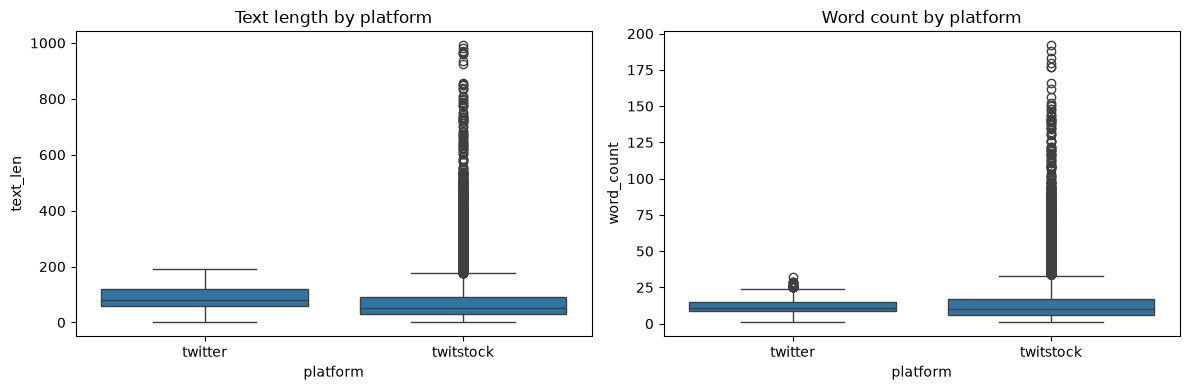

Twitter n=9543, TwitStock n=19998
Mann-Whitney on text_len: U=126679910.0, p=0


In [25]:
# 2) length distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=posts, x="platform", y="text_len", ax=axes[0])
axes[0].set_title("Text length by platform")

sns.boxplot(data=posts, x="platform", y="word_count", ax=axes[1])
axes[1].set_title("Word count by platform")

plt.tight_layout()
plt.show()

# Mann-Whitney: are length distributions different?
# drop NaNs first — missing text_len values make U/p become NaN
tw_len = posts.loc[posts["platform"] == "twitter", "text_len"].dropna()
ts_len = posts.loc[posts["platform"] == "twitstock", "text_len"].dropna()
print(f"Twitter n={len(tw_len)}, TwitStock n={len(ts_len)}")

u_stat, u_p = stats.mannwhitneyu(tw_len, ts_len, alternative="two-sided")
print(f"Mann-Whitney on text_len: U={u_stat:.1f}, p={u_p:.3g}")



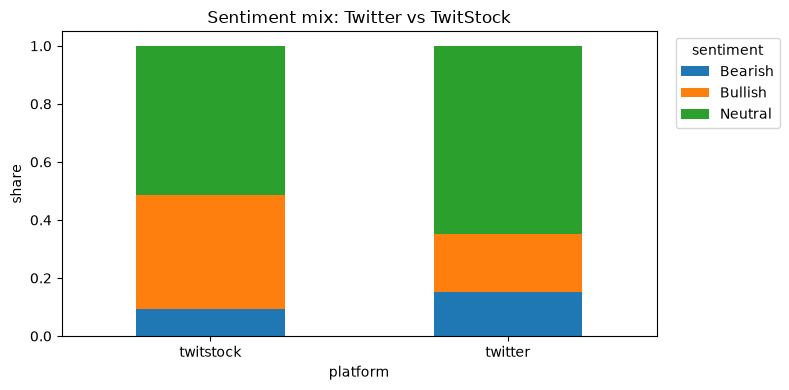

Contingency table (counts):
sentiment  Bearish  Bullish  Neutral
platform                            
twitstock     1850     7876    10274
twitter       1442     1923     6178

Chi-square test on sentiment vs platform: chi2=1126.66, dof=2, p=2.24e-245


In [26]:
# 3) sentiment mix chart + chi-square
sentiment_counts = (
    posts.groupby(["platform", "sentiment"]).size()
    .unstack(fill_value=0)
    [["Bearish", "Bullish", "Neutral"]]
)

ax = sentiment_counts.div(sentiment_counts.sum(axis=1), axis=0).plot(
    kind="bar", stacked=True, figsize=(8, 4), rot=0
)
ax.set_ylabel("share")
ax.set_title("Sentiment mix: Twitter vs TwitStock")
ax.legend(title="sentiment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

chi2, p, dof, expected = stats.chi2_contingency(sentiment_counts.values)
print("Contingency table (counts):")
print(sentiment_counts)
print(f"\nChi-square test on sentiment vs platform: chi2={chi2:.2f}, dof={dof}, p={p:.3g}")



Top cashtags in Twitter sample:
text
$SPY      26
$COMDX    23
$TSLA     20
$SCANX    16
$SUMRX    13
$NVDA     12
$USO      12
$MDCO     11
$ECONX    11
$AAPL     10
$UBER     10
$AMZN     10
$IWM      10
$DIS       9
$WIRES     9
Name: count, dtype: int64


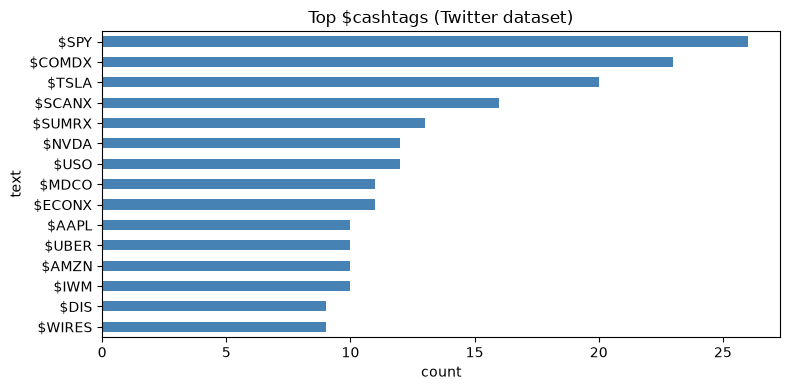

In [27]:
# 4) optional: top cashtags on Twitter side (StockTwits text was stripped of cashtags in preprocessing)
def extract_cashtags(text: str):
    return [m.upper() for m in CASHTAG_RE.findall(text)]

twitter_tags = (
    alt_data["twitter"]["text"].map(extract_cashtags).explode().dropna()
)
top_tags = twitter_tags.value_counts().head(15)

print("Top cashtags in Twitter sample:")
print(top_tags)

fig, ax = plt.subplots(figsize=(8, 4))
top_tags.iloc[::-1].plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top $cashtags (Twitter dataset)")
ax.set_xlabel("count")
plt.tight_layout()
plt.show()



### Takeaways

- Both sources sit in the same schema (`alt_data` + `posts`), so later modeling can swap platforms without rewriting cleaning code.
- Sentiment mixes usually differ between finance Twitter and StockTwits-style posts — the chi-square check flags whether that difference is large.
- Text length / word count often differ too (Twitter finance blurbs vs trader posts).
- Cashtags are mainly informative on the Twitter file; the StockTwits-crypto release already stripped cashtags during preprocessing.

Next step (if needed): join daily sentiment aggregates to market returns (e.g. IVV / mega-cap names) and test predictive value.
